In [1]:
from upxo.ggrowth.mcgs import mcgs
from upxo.analysis.analysis2d import gsan2d
from upxo.analysis.analysis2d import kmodel
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
pxt = mcgs(input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\interfaces\\user_inputs\\input_dashboard_profiling_alg202a.xls')
pxt.simulate()
pxt.detect_grains()

gsan = gsan2d.from_gsstack_temporal(pxt, detect_grains=False, gsids=[], ispxtal=True, prechar=False, 
                                    npixels=False, npixels_gb=False, gb_length_px=False,
                                    eq_diameter=False, feret_diameter=False,
                                    perimeter=False, perimeter_crofton=False, aspect_ratio=True,
                                    compactness=False, solidity=True, morph_ori=False,
                                    circularity=False, eccentricity=True,
                                    euler_number=True, moments_hu=True,
                                    char_gb=False, get_grain_coords=True)
# Mitigating numba crash by calling the function for each gsid separately.
for gsid in gsan.gsstack.keys():
    gsan.gsstack[gsid].find_neigh()

gsan.extract_props()

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\input_dashboard_profiling_alg202a.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 1000.0, 1.0
     No. of states: 5
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|
Using scikit-image for grain identification
MC state = 1:  Num grains = 225
MC state = 2:  Num grains = 216
MC state = 3:  Num grains = 253
MC state = 4:  Num grains = 198
MC state = 5:  Num grains = 227
Te

In [3]:
kmods = [kmodel(gsan.gsstack[gsid].make_graph(gsan.gsstack[gsid].neigh_gid)) for gsid in gsan.gsstack.keys()]

In [4]:
nrounds = 50

In [5]:
n_decomposition_layers_np_m = {tslice: None for tslice in gsan.gsstack.keys()}
n_decomposition_layers_pd_m = {tslice: None for tslice in gsan.gsstack.keys()}
partitions_m = {tslice: None for tslice in gsan.gsstack.keys()}
for i, kmod in enumerate(kmods):
    n_decomposition_layers_np, n_decomposition_layers_pd, partitions = kmod.partition_into_nonconnected_sets_mis_nrealizations(nrounds, see_results=False,
                                                            see_types=['heatmap', 'mean_std'],
                                                            figsize=(5,3), dpi=100, save_partitions=True, throw_pd=True,
                                                            normalize_ng=True,
                                                            vmax=0.5
                                                            )
    n_decomposition_layers_np_m[i] = n_decomposition_layers_np
    n_decomposition_layers_pd_m[i] = n_decomposition_layers_pd
    partitions_m[i] = partitions

Progress: 
  completed.
        PD1   PD2   PD3   PD4   PD5   PD6   PD7   PD8
count  50.0  50.0  50.0  50.0  50.0  50.0  50.0  50.0
mean    0.5   0.2   0.1   0.1   0.0   0.0   0.0   0.0
std     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
min     0.5   0.2   0.1   0.1   0.0   0.0   0.0   0.0
25%     0.5   0.2   0.1   0.1   0.0   0.0   0.0   0.0
50%     0.5   0.2   0.1   0.1   0.0   0.0   0.0   0.0
75%     0.5   0.3   0.1   0.1   0.0   0.0   0.0   0.0
max     0.5   0.3   0.2   0.1   0.0   0.0   0.0   0.0

 Note: PDn indicates peel depth n.
Progress: 
  completed.
        PD1   PD2   PD3   PD4   PD5   PD6   PD7
count  50.0  50.0  50.0  50.0  50.0  50.0  50.0
mean    0.5   0.2   0.1   0.1   0.0   0.0   0.0
std     0.0   0.0   0.0   0.0   0.0   0.0   0.0
min     0.4   0.2   0.1   0.1   0.0   0.0   0.0
25%     0.5   0.2   0.1   0.1   0.0   0.0   0.0
50%     0.5   0.2   0.1   0.1   0.0   0.0   0.0
75%     0.5   0.2   0.2   0.1   0.0   0.0   0.0
max     0.5   0.3   0.2   0.1   0.1   0.0   0.

In [6]:
'''colors = sns.color_palette("nipy_spectral", len(n_decomposition_layers_pd_m.keys()))
plt.figure(figsize=(6,4), dpi=120)
for i in n_decomposition_layers_pd_m.keys():
    sns.lineplot(data=n_decomposition_layers_pd_m[i].mean(0),
                 label=f'Tslice {i}',
                 linewidth=1, color=colors[i])
plt.xlabel('Decomposition Round (Peel Depth)')
plt.ylabel('Normalized Number of cells in MIS')
plt.title('MIS Size Distribution per Decomposition Round')
plt.legend()
plt.show()'''

'colors = sns.color_palette("nipy_spectral", len(n_decomposition_layers_pd_m.keys()))\nplt.figure(figsize=(6,4), dpi=120)\nfor i in n_decomposition_layers_pd_m.keys():\n    sns.lineplot(data=n_decomposition_layers_pd_m[i].mean(0),\n                 label=f\'Tslice {i}\',\n                 linewidth=1, color=colors[i])\nplt.xlabel(\'Decomposition Round (Peel Depth)\')\nplt.ylabel(\'Normalized Number of cells in MIS\')\nplt.title(\'MIS Size Distribution per Decomposition Round\')\nplt.legend()\nplt.show()'

In [7]:
"""from scipy.optimize import curve_fit
def exp_fit(x, a, b, c):
    return a * np.exp(b * x) + c
print("Exponential Fit Parameters for a*np.exp(b*x)+c")
fit_params = {}
std = {}
for i in n_decomposition_layers_pd_m.keys():
    ydata = n_decomposition_layers_pd_m[i].mean(0).values
    xdata = np.arange(len(ydata))
    popt, pcov = curve_fit(exp_fit, xdata, ydata, p0=(1, -0.1, 0))
    perr = np.sqrt(np.diag(pcov))
    std[i] = perr
    fit_params[i] = popt
    print(f'Tslice {i}: a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}')

# plotting each fit smoothly against sparse original data
plt.figure(figsize=(6,4), dpi=120)
x_smooth = np.linspace(0, 8, 200)
for i in n_decomposition_layers_pd_m.keys():
    ydata = n_decomposition_layers_pd_m[i].mean(0).values
    xdata = np.arange(len(ydata))
    y_smooth = exp_fit(x_smooth, *fit_params[i])
    sns.lineplot(x=x_smooth, y=y_smooth,
                 label=f'gsid:{i} Fit: '+f'a={fit_params[i][0]:.2f}, b={fit_params[i][1]:.2f}, c={fit_params[i][2]:.2f}',
                 linewidth=1, color=colors[i])
    '''plt.fill_between(x_smooth, 
                     exp_fit(x_smooth, *(fit_params[i] - std[i])), 
                     exp_fit(x_smooth, *(fit_params[i] + std[i])), 
                     color=colors[i], alpha=0.2)'''
    sns.scatterplot(x=xdata, y=ydata,
                    label=f'gsid:{i} Data',
                    s=15, color=None, marker='o', edgecolor=colors[i], alpha=0.2)
plt.xlabel('Decomposition Round (Peel Depth)')
plt.ylabel('Normalized Number of cells in MIS')
plt.title('Exponential Fit to MIS Size Distribution per Decomposition Round')
plt.legend(fontsize=8)
plt.show()

"""

'from scipy.optimize import curve_fit\ndef exp_fit(x, a, b, c):\n    return a * np.exp(b * x) + c\nprint("Exponential Fit Parameters for a*np.exp(b*x)+c")\nfit_params = {}\nstd = {}\nfor i in n_decomposition_layers_pd_m.keys():\n    ydata = n_decomposition_layers_pd_m[i].mean(0).values\n    xdata = np.arange(len(ydata))\n    popt, pcov = curve_fit(exp_fit, xdata, ydata, p0=(1, -0.1, 0))\n    perr = np.sqrt(np.diag(pcov))\n    std[i] = perr\n    fit_params[i] = popt\n    print(f\'Tslice {i}: a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}\')\n\n# plotting each fit smoothly against sparse original data\nplt.figure(figsize=(6,4), dpi=120)\nx_smooth = np.linspace(0, 8, 200)\nfor i in n_decomposition_layers_pd_m.keys():\n    ydata = n_decomposition_layers_pd_m[i].mean(0).values\n    xdata = np.arange(len(ydata))\n    y_smooth = exp_fit(x_smooth, *fit_params[i])\n    sns.lineplot(x=x_smooth, y=y_smooth,\n                 label=f\'gsid:{i} Fit: \'+f\'a={fit_params[i][0]:.2f}, b={fit_params[

In [8]:
"""for i in n_decomposition_layers_pd_m.keys():
    # plotting each fit smoothly against sparse original data
    plt.figure(figsize=(3,2), dpi=100)
    x_smooth = np.linspace(0, 8, 200)
    i = 0
    ydata = n_decomposition_layers_pd_m[i].mean(0).values
    xdata = np.arange(len(ydata))
    y_smooth = exp_fit(x_smooth, *fit_params[i])
    sns.lineplot(x=x_smooth, y=y_smooth,
                    label=f'gsid:{i} Fit:'+f'a={fit_params[i][0]:.2f}, b={fit_params[i][1]:.2f}, c={fit_params[i][2]:.2f}',
                    linewidth=1, color=colors[i])
    '''plt.fill_between(x_smooth, 
                        exp_fit(x_smooth, *(fit_params[i] - std[i])), 
                        exp_fit(x_smooth, *(fit_params[i] + std[i])), 
                        color=colors[i], alpha=0.2)'''
    sns.scatterplot(x=xdata, y=ydata,
                    label=f'gsid:{i} Data',
                    s=15, color=None, marker='o', edgecolor=colors[i], alpha=0.2)
    plt.xlabel('Decomposition Round (Peel Depth)',  fontsize=8)
    plt.ylabel('Normalized Number of cells in MIS', fontsize=8)
    plt.title('Exp. Fit to MIS Size Distr. per Decomposition Round', fontsize=8)
    plt.legend(fontsize=6)
    plt.show()"""

"for i in n_decomposition_layers_pd_m.keys():\n    # plotting each fit smoothly against sparse original data\n    plt.figure(figsize=(3,2), dpi=100)\n    x_smooth = np.linspace(0, 8, 200)\n    i = 0\n    ydata = n_decomposition_layers_pd_m[i].mean(0).values\n    xdata = np.arange(len(ydata))\n    y_smooth = exp_fit(x_smooth, *fit_params[i])\n    sns.lineplot(x=x_smooth, y=y_smooth,\n                    label=f'gsid:{i} Fit:'+f'a={fit_params[i][0]:.2f}, b={fit_params[i][1]:.2f}, c={fit_params[i][2]:.2f}',\n                    linewidth=1, color=colors[i])\n    '''plt.fill_between(x_smooth, \n                        exp_fit(x_smooth, *(fit_params[i] - std[i])), \n                        exp_fit(x_smooth, *(fit_params[i] + std[i])), \n                        color=colors[i], alpha=0.2)'''\n    sns.scatterplot(x=xdata, y=ydata,\n                    label=f'gsid:{i} Data',\n                    s=15, color=None, marker='o', edgecolor=colors[i], alpha=0.2)\n    plt.xlabel('Decomposition Round

In [9]:
'''for gsid in gsan.gsstack.keys():
    plt.figure(figsize=(3,2), dpi=100)
    plt.imshow(gsan.gsstack[gsid].lgi)
    plt.xlabel('X (pixels)', fontsize=8)
    plt.ylabel('Y (pixels)', fontsize=8)
    plt.title(f'Grain Structure ID: {gsid}', fontsize=8)
    plt.show()'''

"for gsid in gsan.gsstack.keys():\n    plt.figure(figsize=(3,2), dpi=100)\n    plt.imshow(gsan.gsstack[gsid].lgi)\n    plt.xlabel('X (pixels)', fontsize=8)\n    plt.ylabel('Y (pixels)', fontsize=8)\n    plt.title(f'Grain Structure ID: {gsid}', fontsize=8)\n    plt.show()"

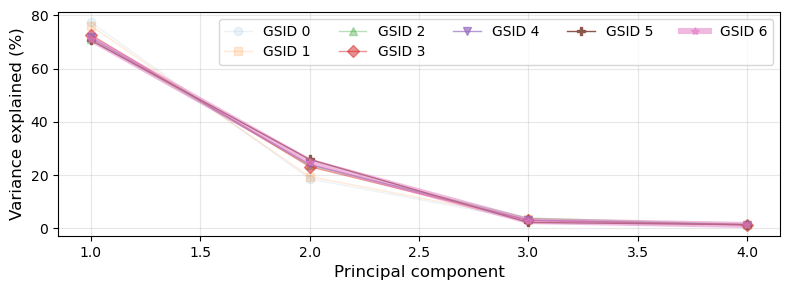

(None, None, None)

In [10]:
pnames=['area', 'major_axis_length', 'minor_axis_length', 'eccentricity']
gsan.pcanalyis(gsids=[], pnames=pnames, auto_ncomp=True, ncomp_method='mle', svd_solver='auto', see_scree=False, annotate=False,)

In [11]:
gsid = 0
trial_number = 1
peel_depth = 1
gids = partitions_m[gsid][trial_number][peel_depth]

In [12]:
gsan.dfs[gsid].iloc[[gid-1 for gid in gids], :]

,area,solidity,eccentricity,euler_number,major_axis_length,minor_axis_length,mhu_1,mhu_2,mhu_3,mhu_4,mhu_5,mhu_6,mhu_7,aspect_ratio
3,1.0,1.00,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
13,1.0,1.00,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
14,3.0,0.75,0.973723,1,3.677089,0.837402,0.296296,0.071331,0.006605,0.001727,0.000005,0.000218,0.000003,4.391067
17,2.0,1.00,1.000000,1,2.000000,0.000000,0.125000,0.015625,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
19,1.0,1.00,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1.0,1.00,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1112,6.0,0.75,0.977048,1,6.011487,1.280549,0.393519,0.129137,0.010320,0.002699,0.000012,0.000709,0.000008,4.694460
1114,1.0,1.00,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1116,1.0,1.00,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


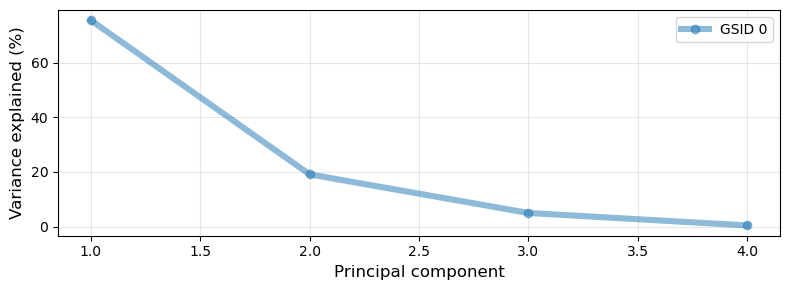

(None, None, None)

In [13]:
gsan.pcanalyis(gsids=[gsid], gids = gids, pnames=pnames, auto_ncomp=True, ncomp_method='mle', svd_solver='auto', see_scree=False, annotate=False,)

PD: 1, #GIDs: 53, area: 0.7, major_axis_length: 0.26, minor_axis_length: 0.03, eccentricity: 0.01
PD: 2, #GIDs: 42, area: 0.71, major_axis_length: 0.25, minor_axis_length: 0.03, eccentricity: 0.01
PD: 3, #GIDs: 23, area: 0.71, major_axis_length: 0.27, minor_axis_length: 0.01, eccentricity: 0.01
PD: 4, #GIDs: 12, area: 0.74, major_axis_length: 0.25, minor_axis_length: 0.01, eccentricity: 0.0
PD: 5, #GIDs: 8, area: 0.76, major_axis_length: 0.23, minor_axis_length: 0.01, eccentricity: 0.01
Skipping peel depth 6 due to insufficient GIDs.


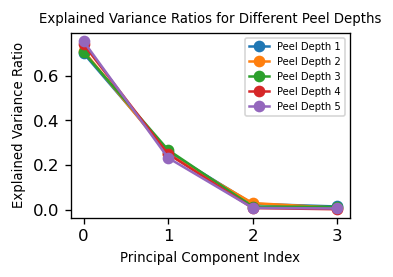

In [14]:
gsid = 5
trial_number = 1

plt.figure(figsize=(3, 2), dpi=120)

for peel_depth in partitions_m[gsid][trial_number].keys():
    gids = partitions_m[gsid][trial_number][peel_depth]
    if len(gids) <= len(pnames):
        print('Skipping peel depth', peel_depth, 'due to insufficient GIDs.')
        continue
    pca, scores, exvar = gsan.pcanalyis(gsids=[gsid], gids=gids, pnames=pnames, 
                                auto_ncomp=True, ncomp_method='mle', svd_solver='auto',
                                saa=False, throw=True,
                                see_scree=False, annotate=False, see_exvar=False, see_cum_exvar=False)
    string = []
    for i, pname in enumerate(pnames):
        string.append(f"{pname}: {np.round(exvar[gsid][i], 2)}")
    # Display as one string
    string = ", ".join(string)
    print(f'PD: {peel_depth}, #GIDs: {len(gids)}, {string}')
    plt.plot(exvar[gsid], marker='o', label=f'Peel Depth {peel_depth}')
plt.xlabel('Principal Component Index', fontsize=8)
plt.ylabel('Explained Variance Ratio', fontsize=8)
plt.title('Explained Variance Ratios for Different Peel Depths', fontsize=8)
plt.legend(fontsize=6)
plt.show()

In [15]:
from copy import deepcopy
from scipy.ndimage import binary_erosion

In [141]:
gsid=6
structure = np.ones((3, 3), dtype=bool)
niterations = 1

for gid in gsan.gsstack[gsid].gid:
    grain = gsan.gsstack[gsid].g[gid]['grain']
    g_bbox = deepcopy(grain.bbox)
    # Sinxce we do not know how many iterations will be possible, we store all intermediate results in a list.
    bz_all = []
    for i in np.arange(1, niterations+1):
        bz = binary_erosion(g_bbox, iterations=i, structure=structure)
        if not np.any(bz):
            break
        bz_all.append(bz)
    # Storing the last successful erosion as the boundary zone.
    if len(bz_all) == 0:
        gsan.gsstack[gsid].g[gid]['grain'].bbox_bz = g_bbox
        gsan.gsstack[gsid].g[gid]['grain'].bbox_core = None
    else:
        gsan.gsstack[gsid].g[gid]['grain'].bbox_bz = bz_all[-1]
        gsan.gsstack[gsid].g[gid]['grain'].bbox_core = g_bbox - bz_all[-1]

In [142]:
lgi_new = deepcopy(gsan.gsstack[gsid].lgi)

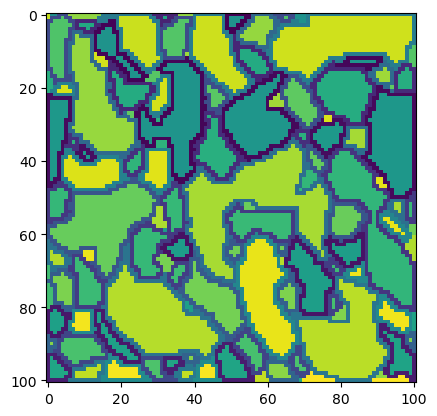

In [143]:
gid_max = max(gsan.gsstack[gsid].gid)+1
for gid in gsan.gsstack[gsid].gid:
    bounds = gsan.gsstack[gsid].g[gid]['grain'].bbox_bounds
    for r, c in np.argwhere(gsan.gsstack[gsid].g[gid]['grain'].bbox_bz):
        lgi_new[r+bounds[0], c+bounds[2]] = gid_max
    gid_max += 1

plt.imshow(lgi_new, cmap='viridis')